# Object Detection with Transformers
In this notebook, we move away from CNNs and use a Transformer model called DETR (DEtection TRansformer).

Transformers were originally built for language (like ChatGPT), but they are now very powerful for computer vision. We will use the Hugging Face library, which makes using these complex models very easy.

## What you will do:

- Install the transformers library.

- Load the DETR model pipeline.

- Detect objects in an image.

- Adjust the confidence threshold to filter out weak detections.

In [ ]:
#@title Installation
# We need to install the Hugging Face libraries first
# timm is a library for image models, pillow is for image handling
!pip install -q transformers timm pillow

print("Libraries installed.")

Libraries installed.


In [ ]:
#@title Imports and Setup
from transformers import pipeline
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Helper function to load an image from the web
def load_image(url):
    return Image.open(requests.get(url, stream=True).raw)

print("Setup complete.")

Setup complete.


In [ ]:
#@title The Detection Pipeline
# We create an 'object-detection' pipeline.
# This downloads the model automatically.
# We are using a ResNet-50 backbone with the DETR architecture.
print("Loading model... this may take a minute.")
object_detector = pipeline("object-detection", model="facebook/detr-resnet-50")
print("Model loaded.")

Loading model... this may take a minute.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


Model loaded.


In [ ]:
#@title Running Inference
# --- STUDENT PLAY ZONE: CHANGE THE IMAGE URL ---
# Try finding an image with multiple objects (e.g., a street scene, a kitchen)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# -----------------------------------------------

image = load_image(url)

# Run the AI on the image
results = object_detector(image)

# Print the raw data to see what the AI found
for item in results:
    print(item)

{'score': 0.9982202649116516, 'label': 'remote', 'box': {'xmin': 40, 'ymin': 70, 'xmax': 175, 'ymax': 117}}
{'score': 0.9960021376609802, 'label': 'remote', 'box': {'xmin': 333, 'ymin': 72, 'xmax': 368, 'ymax': 187}}
{'score': 0.9954743981361389, 'label': 'couch', 'box': {'xmin': 0, 'ymin': 1, 'xmax': 639, 'ymax': 473}}
{'score': 0.99880051612854, 'label': 'cat', 'box': {'xmin': 13, 'ymin': 52, 'xmax': 314, 'ymax': 470}}
{'score': 0.9986783862113953, 'label': 'cat', 'box': {'xmin': 345, 'ymin': 23, 'xmax': 640, 'ymax': 368}}


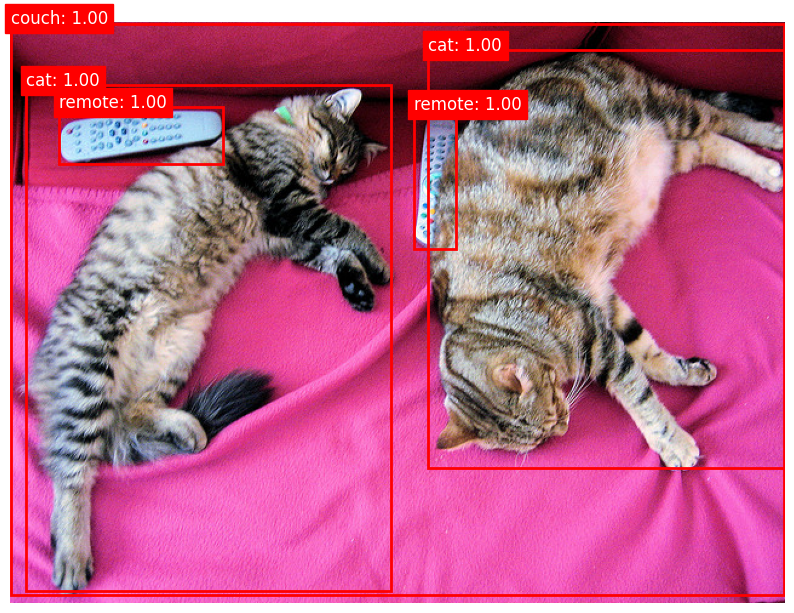

In [ ]:
#@title Visualization with Threshold
# --- STUDENT PLAY ZONE: ADJUST CONFIDENCE ---
# 0.9 means the AI must be 90% sure.
# Lower this to 0.5 to see 'guesses'. Raise it to 0.99 for high precision.
CONFIDENCE_THRESHOLD = 0.9
# --------------------------------------------

# Create a plot
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image)

# Loop through every object detected
for result in results:
    score = result['score']
    label = result['label']
    box = result['box'] # Contains xmin, ymin, xmax, ymax

    # Only show the box if the AI is confident enough
    if score > CONFIDENCE_THRESHOLD:
        # Create a rectangle patch
        rect = patches.Rectangle(
            (box['xmin'], box['ymin']),
            box['xmax'] - box['xmin'],
            box['ymax'] - box['ymin'],
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        # Add the box to the plot
        ax.add_patch(rect)

        # Add the label text
        plt.text(
            box['xmin'],
            box['ymin'],
            f"{label}: {score:.2f}",
            color='white',
            fontsize=12,
            backgroundcolor='red'
        )

plt.axis('off')
plt.show()